# Phase 1 — Data Preprocessing & Exploration

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook performs an Exploratory Data Analysis and develops a preprocessing pipeline on the initial experimental dataset of E. coli under ampicillin exposure.

### Objectives
- Explore and understand the structure and content of the raw dataset
- Define a reusable preprocessing pipeline applicable to all the raw data
- Apply the pipeline to the initial dataset
- Save the preprocessed data as a PKL file

### Output
- `ecoli_ampli.pkl` — cleaned dataset 

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports](#2-imports--setup)
3. [Dataset Preprocessing](#3-dataset-preprocessing)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)

## 2. Imports & Setup

In [1]:
# -- Installation (run once if needed) ------------------------------------------------
# !pip install openpyxl

# -- Data manipulation ----------------------------------------------------------------
from IPython.display import display

# -- Serialisation --------------------------------------------------------------------
import pickle

# -- Project functions ----------------------------------------------------------------
from Preprocessing_functions_1 import *

## 3. Dataset Preprocessing

### 3.1 Load dataset

In [2]:
# Path to the raw data file
path = "C:/Users/eduar/Desktop/Projeto em Bioinformática/Dados/Data_E.coli_25922_ampicillin.xlsx" # Imporante: Change Path

# Load dataset into nested dictionary structure
ecoli_ampli = get_dataset(path)

#Remove or impute missing values across all sheets
ecoli_ampli = clean_Nas(ecoli_ampli)

In [3]:
# Serialise the cleaned dataset for use in later phases
with open("ecoli_ampli.pkl", "wb") as f:
    pickle.dump(ecoli_ampli, f)

print("Dataset saved successfully.")

Dataset saved successfully.


In [4]:
# Display each DataFrame by date, concentration and type
for date in ecoli_ampli:
    for concentration in ecoli_ampli[date]:
        for sample_type in ecoli_ampli[date][concentration]:
            #print(f"\n--- {date}  |  {concentration}  |  {sample_type} ---")
            #display(ecoli_ampli[date][concentration][sample_type])
            None

## 4. Exploratory Data Analysis

### 4.1 Dataset structure overview

In [5]:
# Extract available experiments, concentrations and data types
experiments  = list(ecoli_ampli.keys())
bac_conc     = list(ecoli_ampli[experiments[0]].keys())
data_types   = list(ecoli_ampli[experiments[0]][bac_conc[0]].keys())
biotic_conc  = list(ecoli_ampli["20230508"]["5e4"]["brutos"].columns)[1:]

print("Experiments :", experiments)
print("Concentrations :", bac_conc)
print("Data types :", data_types)
print("Bacteria concentration :", biotic_conc)

Experiments : ['20230508', '20230516', '20230518']
Concentrations : ['5e6', '5e5', '5e4']
Data types : ['brutos', 'gvr']
Bacteria concentration : ['Positive control', 0.5, 1, 2, 4, 8, 16, 32, 64, 128]


### 4.2 Experiment duration per condition

In [6]:
# Compute the total duration (hours) for each experiment and concentration
duration = {}

for date, concentrations in ecoli_ampli.items():
    duration[date] = {}
    for conc, datasets in concentrations.items():
        df = datasets["brutos"]
        last_timepoint = round(df.iloc[-1, 0], 2)
        duration[date][conc] = last_timepoint

print("Duration per condition (hours):")
print(duration)

Duration per condition (hours):
{'20230508': {'5e6': 11.0, '5e5': 13.33, '5e4': 11.0}, '20230516': {'5e6': 18.17, '5e5': 18.17, '5e4': 18.17}, '20230518': {'5e6': 16.33, '5e5': 16.33, '5e4': 16.33}}


### 4.3 Missing value check

In [7]:
# Verify that no NaN values remain after preprocessing
na_found = False

for date, concentrations in ecoli_ampli.items():
    for conc, datasets in concentrations.items():
        for data_type, df in datasets.items():
            if df.isna().any().any():
                print(f"  NAs found in: {date} - {conc} - {data_type}")
                na_found = True

if not na_found:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


### 4.4 Standard deviation analysis (GVR)

Experiment: 20230508  |  Concentration: 5e6
std inicial: 0.0088
std final: 1.4059


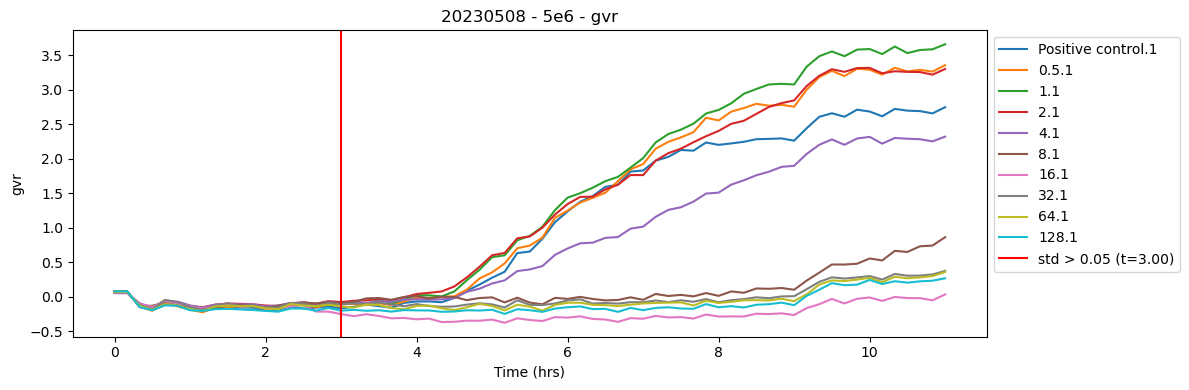


Experiment: 20230508  |  Concentration: 5e5
std inicial: 0.0043
std final: 1.0448


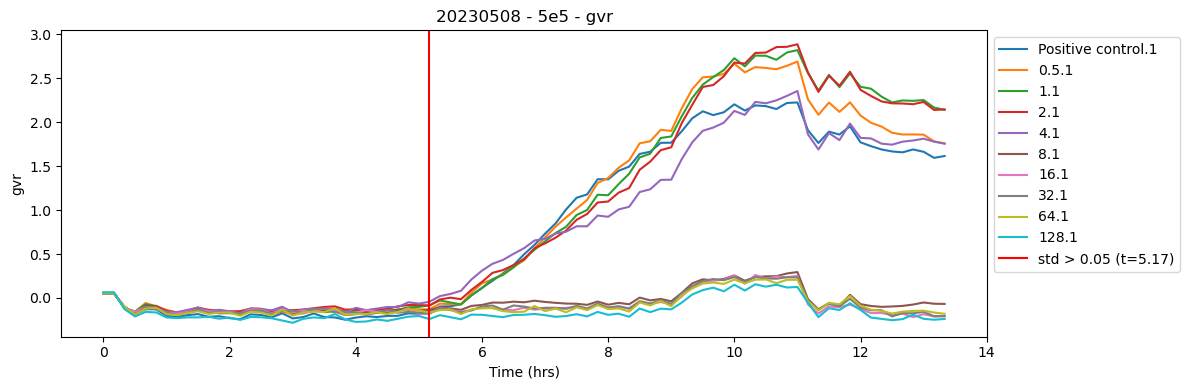


Experiment: 20230508  |  Concentration: 5e4
std inicial: 0.0067
std final: 1.2521


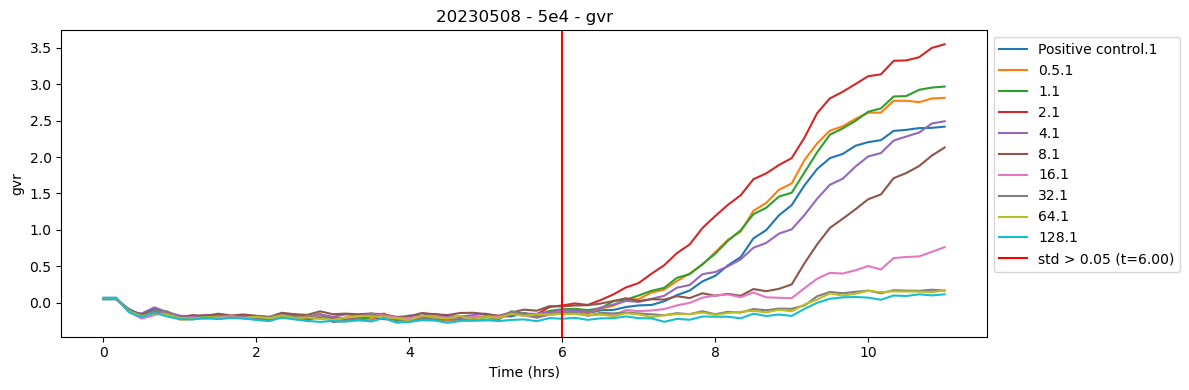


Experiment: 20230516  |  Concentration: 5e6
std inicial: 0.0080
std final: 0.2036


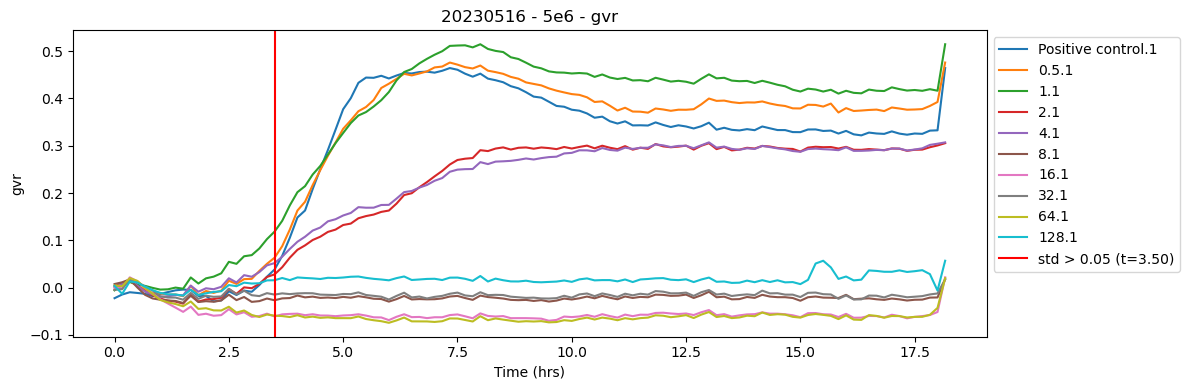


Experiment: 20230516  |  Concentration: 5e5
std inicial: 0.0170
std final: 0.4331


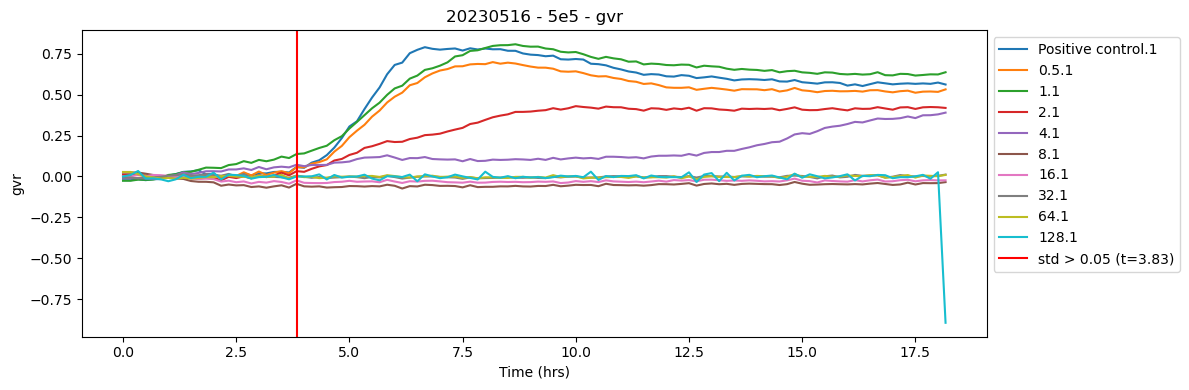


Experiment: 20230516  |  Concentration: 5e4
std inicial: 0.0180
std final: 0.4434


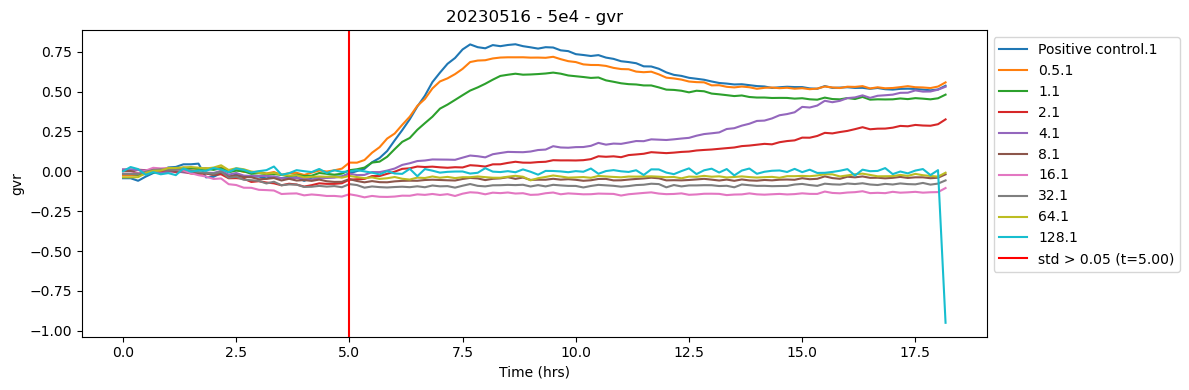


Experiment: 20230518  |  Concentration: 5e6
std inicial: 0.0046
std final: 0.9667


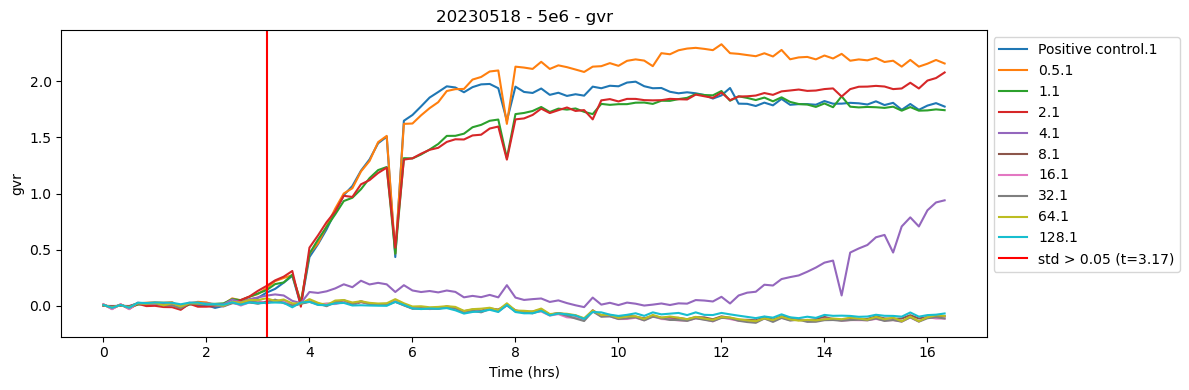


Experiment: 20230518  |  Concentration: 5e5
std inicial: 0.0035
std final: 0.6281


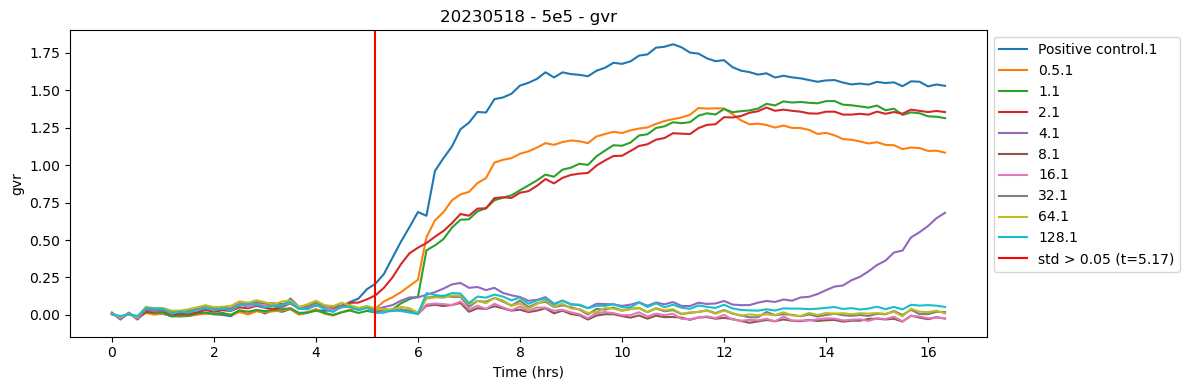


Experiment: 20230518  |  Concentration: 5e4
std inicial: 0.0060
std final: 1.2022


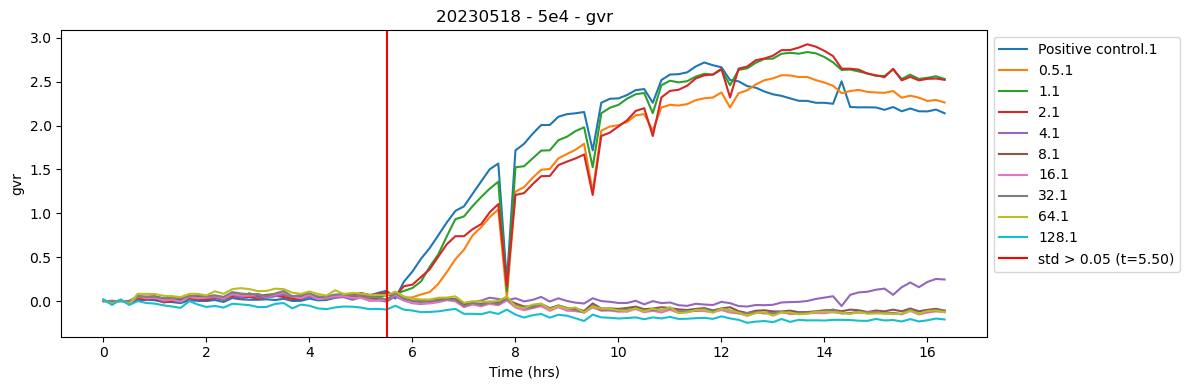

In [8]:
# Plot standard deviation threshold for each experiment and concentration
for date, concentrations in ecoli_ampli.items():
    for conc, datasets in concentrations.items():
        df = datasets["gvr"]

        print(f"Experiment: {date}  |  Concentration: {conc}")
        time_threshold = get_std(df, "std")
        get_fig_std(date, conc, df, "gvr", time_threshold)
        print()